In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_parquet("taxi_2025-07.parquet")


In [7]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-07-01 00:29:37,2025-07-01 00:45:30,1.0,7.30,1.0,N,138,74,1,29.60,7.75,0.5,9.00,6.94,1.0,54.79,0.0,1.75,0.00
1,1,2025-07-01 00:23:28,2025-07-01 01:07:44,1.0,17.70,2.0,N,132,142,1,70.00,4.25,0.5,5.00,0.00,1.0,80.75,2.5,1.75,0.00
2,2,2025-07-01 00:53:50,2025-07-01 01:27:12,1.0,9.98,1.0,N,138,48,1,43.60,6.00,0.5,10.87,0.00,1.0,66.97,2.5,1.75,0.75
3,2,2025-07-01 00:58:49,2025-07-01 01:15:55,1.0,10.27,1.0,N,138,229,1,38.70,6.00,0.5,14.10,6.94,1.0,72.24,2.5,1.75,0.75
4,2,2025-07-01 00:09:22,2025-07-01 00:23:54,1.0,2.94,1.0,N,211,97,1,17.00,1.00,0.5,3.00,0.00,1.0,25.75,2.5,0.00,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3898958,2,2025-07-31 23:43:43,2025-07-31 23:47:49,NaN,0.64,NaN,None,100,170,0,6.39,0.00,0.5,0.00,0.00,1.0,11.14,NaN,NaN,0.75
3898959,2,2025-07-31 23:05:39,2025-07-31 23:34:07,NaN,6.19,NaN,None,249,265,0,-15.81,0.00,0.0,0.00,14.06,1.0,10.00,NaN,NaN,0.75
3898960,2,2025-07-31 23:08:32,2025-07-31 23:34:06,NaN,7.80,NaN,None,151,79,0,32.53,0.00,0.5,0.00,0.00,1.0,37.28,NaN,NaN,0.75
3898961,2,2025-07-31 23:13:56,2025-07-31 23:25:09,NaN,2.09,NaN,None,148,170,0,12.17,0.00,0.5,0.00,0.00,1.0,16.92,NaN,NaN,0.75


In [3]:
ver = df[df['congestion_surcharge'].isna()]

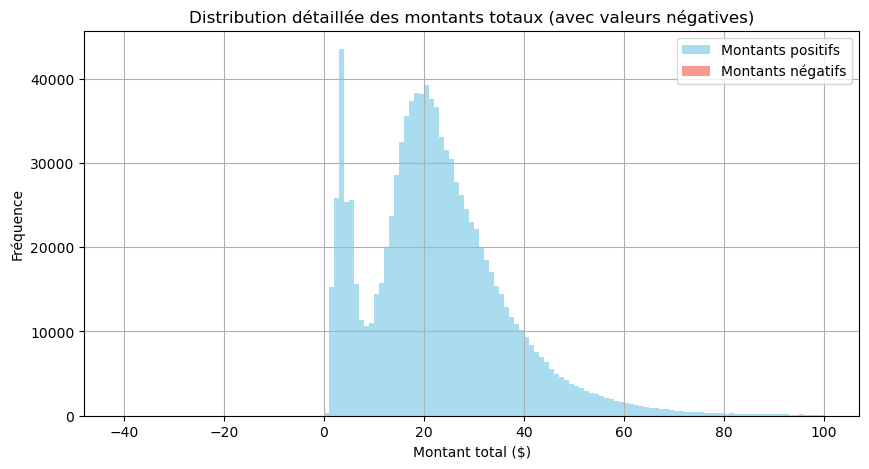

In [11]:
import matplotlib.pyplot as plt

# Créer deux sous-ensembles
negatifs = ver[ver['total_amount'] < 0]
positifs = ver[ver['total_amount'] >= 0]

plt.figure(figsize=(10,5))

# Histogramme principal (valeurs normales)
plt.hist(positifs['total_amount'], bins=100, range=(0,100), alpha=0.7, label='Montants positifs', color='skyblue')

# Histogramme secondaire (valeurs négatives)
plt.hist(negatifs['total_amount'], bins=30, alpha=0.8, label='Montants négatifs', color='salmon')

plt.title("Distribution détaillée des montants totaux (avec valeurs négatives)")
plt.xlabel("Montant total ($)")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
po = ver[ver['total_amount'] < 0].sort_values('total_amount')

In [14]:
po.shape

(23, 20)

In [16]:
po

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3027327,2,2025-07-06 16:33:05,2025-07-06 17:01:54,NaN,9.45,NaN,None,88,202,0,-36.16,0.0,-0.5,0.00,0.0,-1.0,-40.91,NaN,NaN,-0.75
3050489,2,2025-07-07 17:22:41,2025-07-07 17:45:14,NaN,0.00,NaN,None,234,97,0,-27.35,0.0,-0.5,-7.44,0.0,-1.0,-39.54,NaN,NaN,-0.75
3026122,2,2025-07-06 15:10:13,2025-07-06 15:29:55,NaN,3.87,NaN,None,209,230,0,-25.78,0.0,-0.5,-8.59,0.0,-1.0,-39.12,NaN,NaN,-0.75
3453244,2,2025-07-19 14:52:09,2025-07-19 15:24:07,NaN,9.22,NaN,None,198,179,0,-37.43,0.0,-0.5,0.00,0.0,-1.0,-38.93,NaN,NaN,0.00
3102755,2,2025-07-09 17:17:10,2025-07-09 17:22:00,NaN,0.05,NaN,None,181,181,0,-37.30,0.0,-0.5,0.00,0.0,1.0,-37.80,NaN,NaN,0.00
3153318,2,2025-07-11 10:40:10,2025-07-11 10:47:00,NaN,0.56,NaN,None,231,144,0,-33.76,0.0,-0.5,0.00,0.0,1.0,-37.51,NaN,NaN,-0.75
3012964,2,2025-07-06 01:37:55,2025-07-06 02:00:30,NaN,5.43,NaN,None,261,142,0,-30.01,0.0,-0.5,0.00,0.0,-1.0,-34.76,NaN,NaN,-0.75
3848440,2,2025-07-30 20:16:10,2025-07-30 20:23:00,NaN,0.78,NaN,None,48,186,0,-28.60,0.0,-0.5,0.00,0.0,1.0,-32.35,NaN,NaN,-0.75
3395582,2,2025-07-18 00:42:10,2025-07-18 00:44:00,NaN,0.00,NaN,None,211,211,0,-24.53,0.0,-0.5,0.00,0.0,1.0,-28.28,NaN,NaN,-0.75
3357828,2,2025-07-16 23:14:15,2025-07-16 23:29:27,NaN,3.61,NaN,None,113,236,0,-21.33,0.0,-0.5,0.00,0.0,-1.0,-26.08,NaN,NaN,-0.75


In [7]:
ver['total_amount'].value_counts()

total_amount
3.00      18362
1.00      14514
5.00       9193
2.00       4586
6.14       2087
          ...  
104.28        1
165.39        1
78.35         1
95.63         1
101.47        1
Name: count, Length: 10720, dtype: int64

In [5]:
ver1 = ver[ver['total_amount'] < 0.0]

In [17]:
ver1

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2873426,2,2025-07-01 15:02:10,2025-07-01 15:07:00,NaN,0.76,NaN,None,142,143,0,-12.68,0.0,-0.5,-2.64,0.0,1.0,-18.32,NaN,NaN,0.00
2887165,2,2025-07-01 21:02:10,2025-07-01 21:03:00,NaN,0.00,NaN,None,162,162,0,-13.63,0.0,-0.5,0.00,0.0,1.0,-17.38,NaN,NaN,-0.75
2964458,2,2025-07-04 17:24:06,2025-07-04 17:33:30,NaN,1.78,NaN,None,246,113,0,-11.07,0.0,-0.5,0.00,0.0,-1.0,-15.82,NaN,NaN,-0.75
3012964,2,2025-07-06 01:37:55,2025-07-06 02:00:30,NaN,5.43,NaN,None,261,142,0,-30.01,0.0,-0.5,0.00,0.0,-1.0,-34.76,NaN,NaN,-0.75
3023918,2,2025-07-06 14:43:10,2025-07-06 14:44:00,NaN,0.02,NaN,None,100,100,0,-20.48,0.0,-0.5,0.00,0.0,1.0,-24.23,NaN,NaN,-0.75
3026122,2,2025-07-06 15:10:13,2025-07-06 15:29:55,NaN,3.87,NaN,None,209,230,0,-25.78,0.0,-0.5,-8.59,0.0,-1.0,-39.12,NaN,NaN,-0.75
3027327,2,2025-07-06 16:33:05,2025-07-06 17:01:54,NaN,9.45,NaN,None,88,202,0,-36.16,0.0,-0.5,0.00,0.0,-1.0,-40.91,NaN,NaN,-0.75
3050489,2,2025-07-07 17:22:41,2025-07-07 17:45:14,NaN,0.00,NaN,None,234,97,0,-27.35,0.0,-0.5,-7.44,0.0,-1.0,-39.54,NaN,NaN,-0.75
3102755,2,2025-07-09 17:17:10,2025-07-09 17:22:00,NaN,0.05,NaN,None,181,181,0,-37.30,0.0,-0.5,0.00,0.0,1.0,-37.80,NaN,NaN,0.00
3136580,2,2025-07-10 20:48:05,2025-07-10 21:06:21,NaN,4.72,NaN,None,148,141,0,-20.18,0.0,-0.5,0.00,0.0,-1.0,-24.93,NaN,NaN,-0.75


In [15]:
ver1.shape

(23, 20)

In [49]:
cols = ['passenger_count', 'RatecodeID', 'congestion_surcharge', 'Airport_fee', 'store_and_fwd_flag']
df[cols].isna().corr()

,passenger_count,RatecodeID,congestion_surcharge,Airport_fee,store_and_fwd_flag
passenger_count,1.0,1.0,1.0,1.0,1.0
RatecodeID,1.0,1.0,1.0,1.0,1.0
congestion_surcharge,1.0,1.0,1.0,1.0,1.0
Airport_fee,1.0,1.0,1.0,1.0,1.0
store_and_fwd_flag,1.0,1.0,1.0,1.0,1.0


In [50]:
cols = ['VendorID','passenger_count', 'RatecodeID', 'congestion_surcharge', 'Airport_fee','payment_type','fare_amount','extra','mta_tax','tip_amount','tolls_amount',
       'improvement_surcharge','total_amount','cbd_congestion_fee','PULocationID','DOLocationID']
df[cols].corr()

,VendorID,passenger_count,RatecodeID,congestion_surcharge,Airport_fee,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee,PULocationID,DOLocationID
VendorID,1.000000,0.056908,-0.152232,0.039630,0.040437,0.017159,-0.026207,-0.320319,-0.000898,0.018844,-0.003701,0.029972,-0.011607,0.015151,0.011221,0.008208
passenger_count,0.056908,1.000000,-0.054910,-0.016609,0.039385,0.044598,0.060217,-0.059540,-0.003185,0.031297,0.047000,-0.001652,0.057947,0.018583,-0.017722,-0.012885
RatecodeID,-0.152232,-0.054910,1.000000,-0.306989,-0.031569,-0.053445,0.113138,-0.109187,0.000679,-0.107737,0.040771,-0.374807,0.053349,-0.211630,-0.091039,-0.076325
congestion_surcharge,0.039630,-0.016609,-0.306989,1.000000,-0.203518,-0.425060,-0.038969,0.155099,0.038050,0.037061,-0.052023,0.737973,0.031621,0.673230,0.123129,0.108770
Airport_fee,0.040437,0.039385,-0.031569,-0.203518,1.000000,-0.038173,0.564312,0.295532,0.008237,0.403143,0.436346,0.168919,0.593332,-0.146764,-0.139315,-0.039691
payment_type,0.017159,0.044598,-0.053445,-0.425060,-0.038173,1.000000,-0.087653,0.165081,-0.022970,0.040399,-0.005840,-0.412957,-0.086691,-0.169834,0.051709,0.048842
fare_amount,-0.026207,0.060217,0.113138,-0.038969,0.564312,-0.087653,1.000000,0.159471,0.008384,0.495837,0.528159,0.246894,0.968884,0.034083,-0.085388,-0.053606
extra,-0.320319,-0.059540,-0.109187,0.155099,0.295532,0.165081,0.159471,1.000000,0.009651,0.312595,0.201282,0.191511,0.257279,0.112138,0.013635,0.037847
mta_tax,-0.000898,-0.003185,0.000679,0.038050,0.008237,-0.022970,0.008384,0.009651,1.000000,0.000362,-0.000259,0.046142,0.119538,0.020706,0.000357,0.001331
tip_amount,0.018844,0.031297,-0.107737,0.037061,0.403143,0.040399,0.495837,0.312595,0.000362,1.000000,0.388873,0.122945,0.633127,0.075867,-0.005273,0.015273


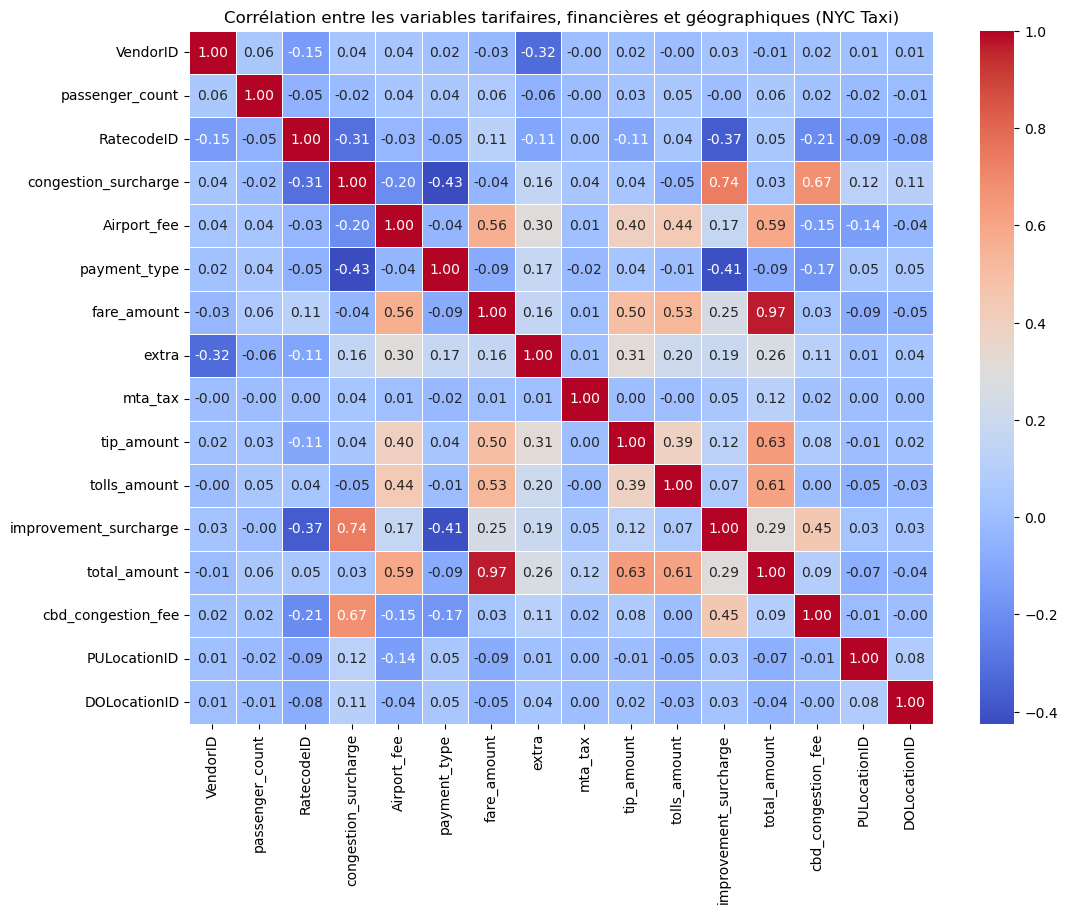

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,9))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Corrélation entre les variables tarifaires, financières et géographiques (NYC Taxi)")
plt.show()

In [83]:
mask = df[['passenger_count', 'RatecodeID', 'congestion_surcharge', 'Airport_fee', 'store_and_fwd_flag']].isna().all(axis=1)
df[mask] 

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2860208,2,2025-07-01 00:06:31,2025-07-01 00:15:59,NaN,2.95,NaN,None,75,48,0,13.93,0.0,0.5,0.0,0.00,1.0,18.68,NaN,NaN,0.75
2860209,2,2025-07-01 00:54:00,2025-07-01 01:00:46,NaN,1.01,NaN,None,68,249,0,6.23,0.0,0.5,0.0,0.00,1.0,10.98,NaN,NaN,0.75
2860210,2,2025-07-01 00:31:20,2025-07-01 00:39:48,NaN,1.64,NaN,None,234,48,0,8.78,0.0,0.5,0.0,0.00,1.0,13.53,NaN,NaN,0.75
2860211,2,2025-07-01 00:32:00,2025-07-01 00:50:00,NaN,2.99,NaN,None,48,4,0,17.39,0.0,0.5,0.0,0.00,1.0,22.14,NaN,NaN,0.75
2860212,2,2025-07-01 00:25:07,2025-07-01 00:40:38,NaN,9.51,NaN,None,75,240,0,32.13,0.0,0.5,0.0,0.00,1.0,33.63,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3898958,2,2025-07-31 23:43:43,2025-07-31 23:47:49,NaN,0.64,NaN,None,100,170,0,6.39,0.0,0.5,0.0,0.00,1.0,11.14,NaN,NaN,0.75
3898959,2,2025-07-31 23:05:39,2025-07-31 23:34:07,NaN,6.19,NaN,None,249,265,0,-15.81,0.0,0.0,0.0,14.06,1.0,10.00,NaN,NaN,0.75
3898960,2,2025-07-31 23:08:32,2025-07-31 23:34:06,NaN,7.80,NaN,None,151,79,0,32.53,0.0,0.5,0.0,0.00,1.0,37.28,NaN,NaN,0.75
3898961,2,2025-07-31 23:13:56,2025-07-31 23:25:09,NaN,2.09,NaN,None,148,170,0,12.17,0.0,0.5,0.0,0.00,1.0,16.92,NaN,NaN,0.75


In [85]:
df.loc[mask].isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1038755
trip_distance                  0
RatecodeID               1038755
store_and_fwd_flag       1038755
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1038755
Airport_fee              1038755
cbd_congestion_fee             0
dtype: int64

In [87]:
mask_missing = df[['passenger_count','RatecodeID','congestion_surcharge','Airport_fee','store_and_fwd_flag']].isna().all(axis=1)
mask_outside = df['PULocationID'] > 263
(df[mask_missing & mask_outside].shape, df[mask_missing].shape)

((262, 20), (1038755, 20))

/var/folders/5v/d1967b116s78bt9_h_0kd2qr0000gp/T/ipykernel_83272/1810576952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='PULocationID', data=df, order=df['PULocationID'].value_counts().index[:20], palette='viridis')


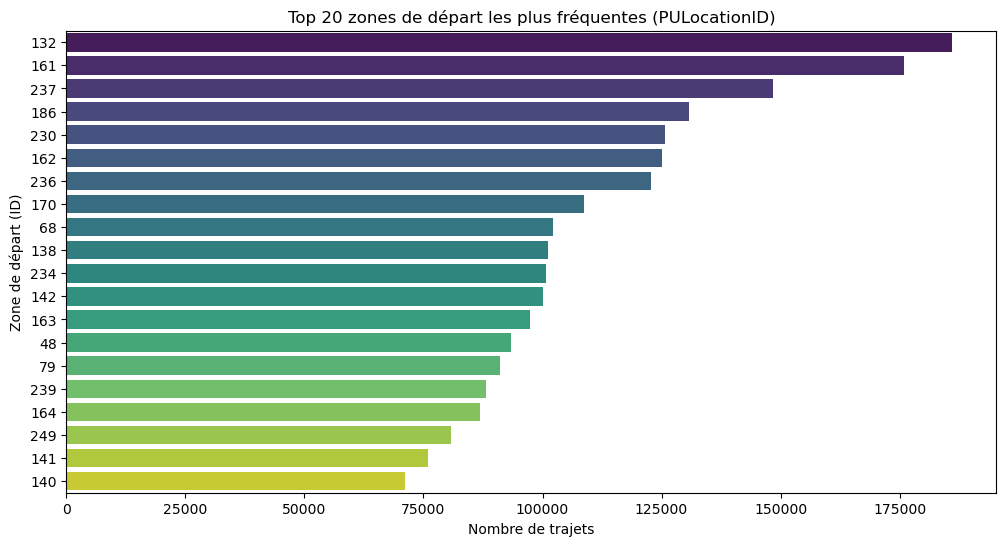

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(y='PULocationID', data=df, order=df['PULocationID'].value_counts().index[:20], palette='viridis')
plt.title("Top 20 zones de départ les plus fréquentes (PULocationID)")
plt.xlabel("Nombre de trajets")
plt.ylabel("Zone de départ (ID)")
plt.show()

In [91]:
cols_manquantes = ['passenger_count', 'RatecodeID', 'congestion_surcharge', 'Airport_fee', 'store_and_fwd_flag']

# Calcul du pourcentage de valeurs manquantes par zone
missing_by_zone = df.groupby('PULocationID')[cols_manquantes].apply(lambda x: x.isna().mean() * 100)

# Moyenne du taux de valeurs manquantes sur toutes les colonnes du bloc
missing_by_zone['taux_moyen'] = missing_by_zone.mean(axis=1)

# Trier les zones avec le plus de valeurs manquantes
missing_by_zone = missing_by_zone.sort_values('taux_moyen', ascending=False)
missing_by_zone.head(10)

,passenger_count,RatecodeID,congestion_surcharge,Airport_fee,store_and_fwd_flag,taux_moyen
PULocationID,,,,,,
176,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
172,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
245,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
214,96.428571,96.428571,96.428571,96.428571,96.428571,96.428571
115,94.117647,94.117647,94.117647,94.117647,94.117647,94.117647
36,91.629393,91.629393,91.629393,91.629393,91.629393,91.629393
198,91.485149,91.485149,91.485149,91.485149,91.485149,91.485149
112,90.185354,90.185354,90.185354,90.185354,90.185354,90.185354
37,90.137025,90.137025,90.137025,90.137025,90.137025,90.137025


/var/folders/5v/d1967b116s78bt9_h_0kd2qr0000gp/T/ipykernel_83272/3857419520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_by_zone.index[:15],


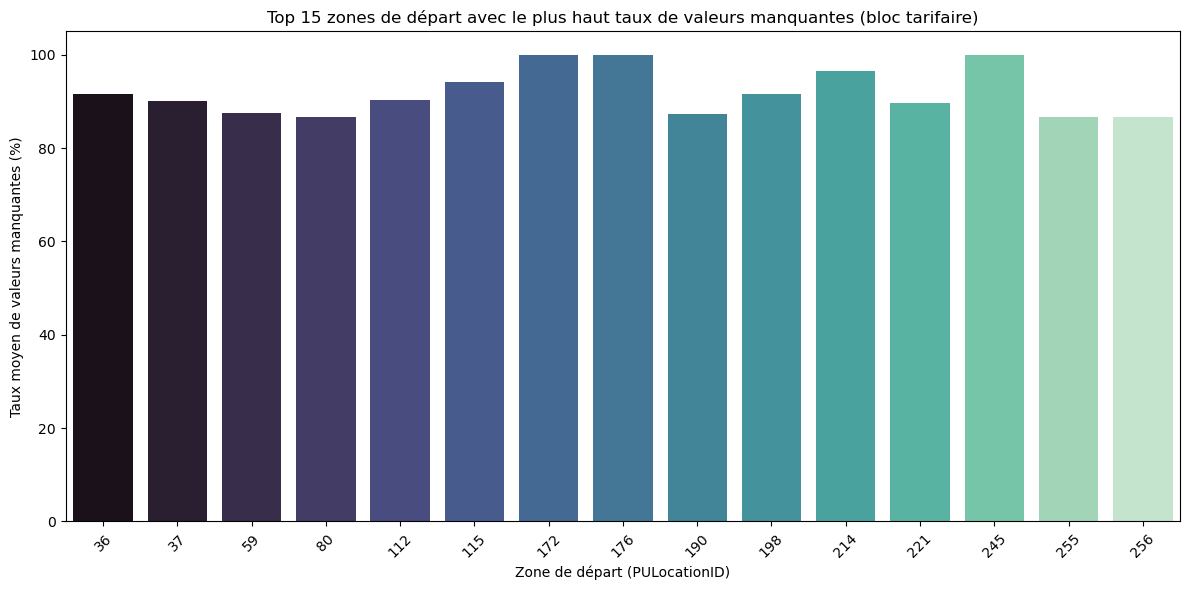

In [94]:
plt.figure(figsize=(12,6))
sns.barplot(x=missing_by_zone.index[:15],
            y=missing_by_zone['taux_moyen'][:15],
            palette='mako')

plt.title("Top 15 zones de départ avec le plus haut taux de valeurs manquantes (bloc tarifaire)")
plt.ylabel("Taux moyen de valeurs manquantes (%)")
plt.xlabel("Zone de départ (PULocationID)")
plt.xticks(rotation=45)  # Incline les étiquettes
plt.tight_layout()
plt.show()

In [96]:
cols_manquantes = ['passenger_count', 'RatecodeID', 'congestion_surcharge', 'Airport_fee', 'store_and_fwd_flag']

# Calcul du taux de valeurs manquantes par zone d’arrivée
missing_by_drop = df.groupby('DOLocationID')[cols_manquantes].apply(lambda x: x.isna().mean() * 100)

# Moyenne du taux sur toutes les colonnes du bloc
missing_by_drop['taux_moyen'] = missing_by_drop.mean(axis=1)

# Trier par taux décroissant
missing_by_drop = missing_by_drop.sort_values('taux_moyen', ascending=False)
missing_by_drop.head(10)

,passenger_count,RatecodeID,congestion_surcharge,Airport_fee,store_and_fwd_flag,taux_moyen
DOLocationID,,,,,,
184,74.895397,74.895397,74.895397,74.895397,74.895397,74.895397
128,72.278912,72.278912,72.278912,72.278912,72.278912,72.278912
126,72.198089,72.198089,72.198089,72.198089,72.198089,72.198089
36,71.747155,71.747155,71.747155,71.747155,71.747155,71.747155
57,70.879121,70.879121,70.879121,70.879121,70.879121,70.879121
73,70.588235,70.588235,70.588235,70.588235,70.588235,70.588235
174,70.377129,70.377129,70.377129,70.377129,70.377129,70.377129
127,70.267380,70.267380,70.267380,70.267380,70.267380,70.267380
20,69.419238,69.419238,69.419238,69.419238,69.419238,69.419238


/var/folders/5v/d1967b116s78bt9_h_0kd2qr0000gp/T/ipykernel_83272/64063925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_by_drop.index[:15],


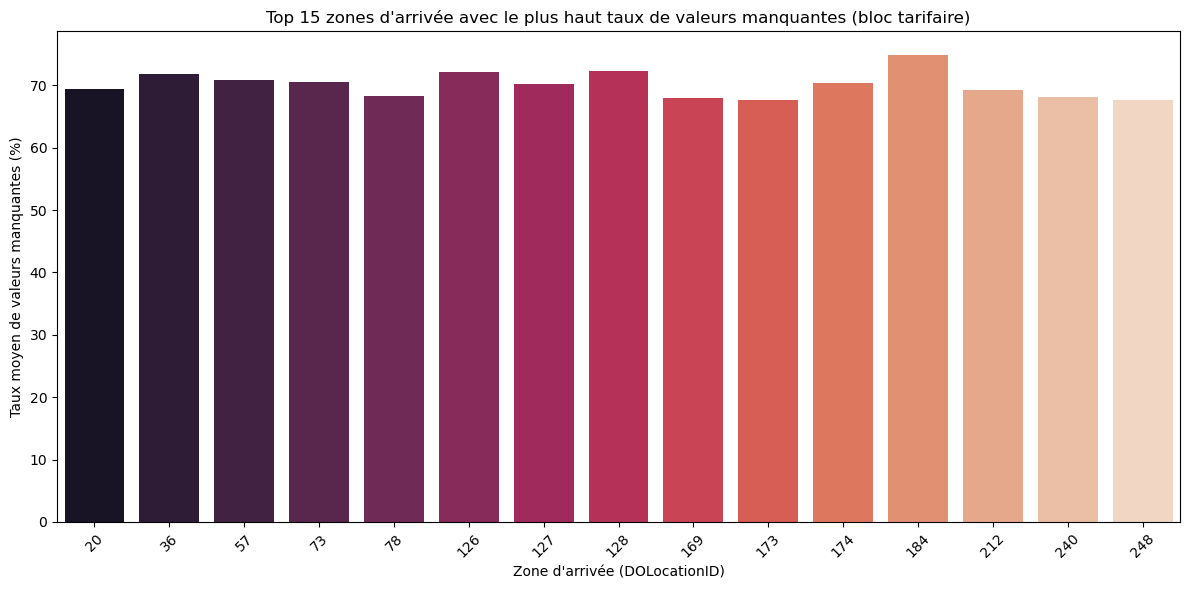

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(x=missing_by_drop.index[:15],
            y=missing_by_drop['taux_moyen'][:15],
            palette='rocket')

plt.title("Top 15 zones d'arrivée avec le plus haut taux de valeurs manquantes (bloc tarifaire)")
plt.ylabel("Taux moyen de valeurs manquantes (%)")
plt.xlabel("Zone d'arrivée (DOLocationID)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [100]:
# Traitement des valeurs manquantes
# Pour passenger_count on vas imputer les differents valeurs manquantes par la mediane == mode == 1
mode = df['passenger_count'].mode()[0]

# Remplacer les valeurs manquantes par le mode
df['passenger_count'].fillna(mode, inplace=True)

# Vérification après imputation
df['passenger_count'].isna().sum()

/var/folders/5v/d1967b116s78bt9_h_0kd2qr0000gp/T/ipykernel_83272/2037303617.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(mode, inplace=True)


0

In [102]:
# Corrige intelligemment les valeurs manquantes de RatecodeID selon la zone

# Si départ ou arrivée = JFK (132) ou LaGuardia (138) → code 2 (tarif aéroport NY)
df.loc[
    (df['RatecodeID'].isna()) &
    ((df['PULocationID'].isin([132, 138])) | (df['DOLocationID'].isin([132, 138]))),
    'RatecodeID'
] = 2

# Si départ ou arrivée = Newark (1) → code 3 (tarif Newark)
df.loc[
    (df['RatecodeID'].isna()) &
    ((df['PULocationID'] == 1) | (df['DOLocationID'] == 1)),
    'RatecodeID'
] = 3

# Le reste → code 1 (tarif standard)
df['RatecodeID'].fillna(1, inplace=True)

/var/folders/5v/d1967b116s78bt9_h_0kd2qr0000gp/T/ipykernel_83272/2571506006.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RatecodeID'].fillna(1, inplace=True)


In [104]:
# Vérifie la répartition après correction
print(df['RatecodeID'].value_counts())

RatecodeID
1.0     3666612
2.0      115044
99.0      55307
5.0       37925
3.0       12627
4.0       11447
6.0           1
Name: count, dtype: int64


In [106]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count                0
trip_distance                  0
RatecodeID                     0
store_and_fwd_flag       1038755
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1038755
Airport_fee              1038755
cbd_congestion_fee             0
dtype: int64

In [108]:
df['store_and_fwd_flag'].value_counts(dropna=False)

store_and_fwd_flag
N       2848340
None    1038755
Y         11868
Name: count, dtype: int64

In [110]:
# Remplace les valeurs manquantes par 'N' (transmission directe)
df['store_and_fwd_flag'].fillna('N', inplace=True)

/var/folders/5v/d1967b116s78bt9_h_0kd2qr0000gp/T/ipykernel_83272/826353212.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['store_and_fwd_flag'].fillna('N', inplace=True)


In [112]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count                0
trip_distance                  0
RatecodeID                     0
store_and_fwd_flag             0
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1038755
Airport_fee              1038755
cbd_congestion_fee             0
dtype: int64

In [114]:
df['congestion_surcharge'].value_counts()

congestion_surcharge
 2.50    2513544
 0.00     288005
-2.50      58655
 1.00          3
 0.75          1
Name: count, dtype: int64

In [120]:
zone = pd.read_csv('taxi_zone_lookup.csv')
zone

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN


In [122]:
manhattan_ids = zone.loc[zone["Borough"] == "Manhattan", "LocationID"].tolist()
 
print(manhattan_ids)

[4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90, 100, 103, 104, 105, 107, 113, 114, 116, 120, 125, 127, 128, 137, 140, 141, 142, 143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166, 170, 186, 194, 202, 209, 211, 224, 229, 230, 231, 232, 233, 234, 236, 237, 238, 239, 243, 244, 246, 249, 261, 262, 263]


In [ ]:
df

In [124]:
surcharge = df[df['congestion_surcharge']>0]

In [126]:
# Determiner les lieux ou les tarifs sont appliques a manhattan ou pas
sur = (surcharge ['PULocationID'].isin(manhattan_ids) | surcharge ['DOLocationID'].isin(manhattan_ids))

In [128]:
sur.value_counts()

True     2506539
False       7009
Name: count, dtype: int64

In [130]:
hors_manhattan = surcharge[
    ~surcharge['PULocationID'].isin(manhattan_ids) &
    ~surcharge['DOLocationID'].isin(manhattan_ids)
]

In [132]:
hors_manhattan

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
13,2,2025-07-01 00:58:09,2025-07-01 01:25:53,2.0,17.46,2.0,N,132,265,2,70.0,0.0,0.5,0.00,6.94,1.0,83.44,2.5,1.75,0.75
641,2,2025-07-01 00:32:05,2025-07-01 00:58:15,4.0,14.57,1.0,N,132,91,1,55.5,1.0,0.5,10.00,0.00,1.0,72.25,2.5,1.75,0.00
791,2,2025-07-01 00:16:15,2025-07-01 00:50:07,1.0,17.54,1.0,N,132,17,1,67.4,1.0,0.5,14.48,0.00,1.0,88.63,2.5,1.75,0.00
822,2,2025-07-01 00:30:49,2025-07-01 00:50:14,3.0,4.88,1.0,N,264,264,1,22.6,1.0,0.5,8.50,0.00,1.0,36.85,2.5,0.00,0.75
864,2,2025-07-01 00:26:57,2025-07-01 01:18:44,1.0,25.01,1.0,N,138,251,1,96.8,6.0,0.5,32.09,20.82,1.0,162.21,2.5,1.75,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859505,2,2025-07-31 23:26:38,2025-07-31 23:51:24,1.0,13.64,4.0,N,132,265,1,79.3,1.0,0.5,21.08,0.00,1.0,107.13,2.5,1.75,0.00
2859519,2,2025-07-31 23:19:17,2025-07-31 23:31:31,1.0,4.22,1.0,N,138,92,1,19.1,6.0,0.5,0.00,0.00,1.0,30.85,2.5,1.75,0.00
2859841,2,2025-07-31 23:55:52,2025-08-01 00:06:38,1.0,5.08,1.0,N,132,28,2,21.9,1.0,0.5,0.00,0.00,1.0,28.65,2.5,1.75,0.00
2860084,2,2025-07-31 23:34:53,2025-07-31 23:45:25,4.0,3.80,1.0,N,132,10,1,17.0,1.0,0.5,4.40,0.00,1.0,28.15,2.5,1.75,0.00


In [134]:
hors_manhattan['congestion_surcharge'].value_counts()

congestion_surcharge
2.5    7008
1.0       1
Name: count, dtype: int64

In [136]:
location = pd.concat([hors_manhattan['PULocationID'],hors_manhattan['DOLocationID']]).unique()

In [138]:
len(location)

184

In [140]:
location

array([132, 264, 138,  55, 226, 260,  78, 195,  70,  96,  66,  93,  65,
       223, 145, 168, 129, 242,  25,  69,  97, 130, 112, 146,  83,  27,
        95,  62, 216,  73,  10, 169,  37, 257, 255, 213,  52, 265, 181,
       193,  92, 250,  33, 253,  61, 225, 122,  15, 134,  80, 198,   7,
       119, 218, 247,  19,   1,  53, 189, 241,  82, 252, 208, 196, 154,
       256,  57,  18, 173, 200,  49, 165, 197, 215, 212, 228,  16,  64,
       133, 135, 207, 136,  85, 217, 180, 188,  56, 124,  17, 219, 159,
       182,  36, 149, 179, 160,   6,  31, 177, 121, 191, 190,  40, 157,
        89, 205,  76, 235,  14,  91, 251,  86,  28,   9,  72, 227, 210,
        39,  38, 102, 108,  63, 221, 155, 131,  51,  71, 220, 203,  54,
        67,  35, 187, 192,  26, 201,  32, 139, 258, 185, 106, 117,  20,
       101, 254, 118,  81, 123, 214,  29,  98,  60,  94, 147,  44, 171,
         3, 248, 174,  22, 259, 175,  11,  58, 167, 156, 115, 150,  77,
        21,  47, 178, 109,  34, 222, 183, 245,  46, 126,   8,  2

In [142]:
all_location = list(manhattan_ids) + list(location)

In [250]:
neg1 =df[df['congestion_surcharge'] < 0]
neg1.shape

(58655, 20)

In [258]:
neg1['total_amount'].value_counts()

total_amount
-83.44    1264
-7.75     1028
-14.05     967
-13.35     947
-11.95     921
          ... 
-74.63       1
-58.04       1
-11.80       1
-95.90       1
-39.94       1
Name: count, Length: 2112, dtype: int64

In [252]:
neg1[['PULocationID','DOLocationID']].value_counts().head()

PULocationID  DOLocationID
230           230             540
237           237             535
161           161             476
132           230             450
236           236             368
Name: count, dtype: int64

In [144]:
df['congestion_surcharge'] = np.where(
    (((df['PULocationID'].isin(all_location)) | (df['DOLocationID'].isin(all_location))) &df['total_amount']>0),
    df['congestion_surcharge'].fillna(2.5),
    df['congestion_surcharge'].fillna(-2.5)
)

In [1]:
df.isnull().sum()

NameError: name 'df' is not defined

In [148]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-07-01 00:29:37,2025-07-01 00:45:30,1.0,7.30,1.0,N,138,74,1,29.60,7.75,0.5,9.00,6.94,1.0,54.79,0.0,1.75,0.00
1,1,2025-07-01 00:23:28,2025-07-01 01:07:44,1.0,17.70,2.0,N,132,142,1,70.00,4.25,0.5,5.00,0.00,1.0,80.75,2.5,1.75,0.00
2,2,2025-07-01 00:53:50,2025-07-01 01:27:12,1.0,9.98,1.0,N,138,48,1,43.60,6.00,0.5,10.87,0.00,1.0,66.97,2.5,1.75,0.75
3,2,2025-07-01 00:58:49,2025-07-01 01:15:55,1.0,10.27,1.0,N,138,229,1,38.70,6.00,0.5,14.10,6.94,1.0,72.24,2.5,1.75,0.75
4,2,2025-07-01 00:09:22,2025-07-01 00:23:54,1.0,2.94,1.0,N,211,97,1,17.00,1.00,0.5,3.00,0.00,1.0,25.75,2.5,0.00,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3898958,2,2025-07-31 23:43:43,2025-07-31 23:47:49,1.0,0.64,1.0,N,100,170,0,6.39,0.00,0.5,0.00,0.00,1.0,11.14,2.5,NaN,0.75
3898959,2,2025-07-31 23:05:39,2025-07-31 23:34:07,1.0,6.19,1.0,N,249,265,0,-15.81,0.00,0.0,0.00,14.06,1.0,10.00,2.5,NaN,0.75
3898960,2,2025-07-31 23:08:32,2025-07-31 23:34:06,1.0,7.80,1.0,N,151,79,0,32.53,0.00,0.5,0.00,0.00,1.0,37.28,2.5,NaN,0.75
3898961,2,2025-07-31 23:13:56,2025-07-31 23:25:09,1.0,2.09,1.0,N,148,170,0,12.17,0.00,0.5,0.00,0.00,1.0,16.92,2.5,NaN,0.75


In [150]:
df['Airport_fee'].value_counts()

Airport_fee
 0.00    2571193
 1.75     269919
-1.75      17228
 6.75       1451
 5.00        417
Name: count, dtype: int64

In [152]:
neg =df[df['Airport_fee'] < 0]

In [154]:
neg.shape

(17228, 20)

In [158]:
neg[['PULocationID','DOLocationID']].value_counts().head()

PULocationID  DOLocationID
132           132             1632
              93               943
              265              664
              230              442
              10               402
Name: count, dtype: int64

In [160]:
neg['payment_type'].value_counts()

payment_type
4    11090
2     4025
3     2108
1        5
Name: count, dtype: int64

In [162]:
df['payment_type'].value_counts()

payment_type
1    2343668
0    1038755
2     383976
4     105080
3      27484
Name: count, dtype: int64

In [164]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count                0
trip_distance                  0
RatecodeID                     0
store_and_fwd_flag             0
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge           0
Airport_fee              1038755
cbd_congestion_fee             0
dtype: int64

In [166]:
# Imputation Airport_fee

In [224]:
airport_location_id =pd.Series([1,132,138])

In [226]:
airport_location_id

0      1
1    132
2    138
dtype: int64

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898963 entries, 0 to 3898962
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [204]:
df.loc[df['Airport_fee'] > 0, 'Airport_fee'].median()

1.75

In [188]:
posi['Airport_fee'].describe()

count    271787.000000
mean          1.781680
std           0.385579
min           1.750000
25%           1.750000
50%           1.750000
75%           1.750000
max           6.750000
Name: Airport_fee, dtype: float64

In [234]:
df['Airport_fee'] = np.where(
    ((df['PULocationID'].isin(airport_location_id))|(df['DOLocationID'].isin(airport_location_id))) & (df['total_amount']>0),
    df['Airport_fee'].fillna(df.loc[df['Airport_fee'] > 0, 'Airport_fee'].median()),
    df['Airport_fee'].fillna(df.loc[df['Airport_fee'] < 0, 'Airport_fee'].median())
)

In [236]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-07-01 00:29:37,2025-07-01 00:45:30,1.0,7.30,1.0,N,138,74,1,29.60,7.75,0.5,9.00,6.94,1.0,54.79,0.0,1.75,0.00
1,1,2025-07-01 00:23:28,2025-07-01 01:07:44,1.0,17.70,2.0,N,132,142,1,70.00,4.25,0.5,5.00,0.00,1.0,80.75,2.5,1.75,0.00
2,2,2025-07-01 00:53:50,2025-07-01 01:27:12,1.0,9.98,1.0,N,138,48,1,43.60,6.00,0.5,10.87,0.00,1.0,66.97,2.5,1.75,0.75
3,2,2025-07-01 00:58:49,2025-07-01 01:15:55,1.0,10.27,1.0,N,138,229,1,38.70,6.00,0.5,14.10,6.94,1.0,72.24,2.5,1.75,0.75
4,2,2025-07-01 00:09:22,2025-07-01 00:23:54,1.0,2.94,1.0,N,211,97,1,17.00,1.00,0.5,3.00,0.00,1.0,25.75,2.5,0.00,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3898958,2,2025-07-31 23:43:43,2025-07-31 23:47:49,1.0,0.64,1.0,N,100,170,0,6.39,0.00,0.5,0.00,0.00,1.0,11.14,2.5,-1.75,0.75
3898959,2,2025-07-31 23:05:39,2025-07-31 23:34:07,1.0,6.19,1.0,N,249,265,0,-15.81,0.00,0.0,0.00,14.06,1.0,10.00,2.5,-1.75,0.75
3898960,2,2025-07-31 23:08:32,2025-07-31 23:34:06,1.0,7.80,1.0,N,151,79,0,32.53,0.00,0.5,0.00,0.00,1.0,37.28,2.5,-1.75,0.75
3898961,2,2025-07-31 23:13:56,2025-07-31 23:25:09,1.0,2.09,1.0,N,148,170,0,12.17,0.00,0.5,0.00,0.00,1.0,16.92,2.5,-1.75,0.75


In [238]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
cbd_congestion_fee       0
dtype: int64